# Translating Model Outputs into a Stakeholder-Ready Decision Memo

## Scenario
All analyses for the meal kit plan launch have been completed. Pre-computed
results from choice modeling, WTP, propensity analysis, MDS positioning,
factor analysis, and MMM are provided below. Synthesize these into a
decision-ready memo that a non-technical stakeholder can act on.

## Pre-computed results are already in the notebook. No data files needed.


In [1]:
# Pre-computed values from all prior meal kit exercises
# ─── Choice model ───────────────────────────────────────────
TOP_DRIVER         = 'dietary_options_yes'
TOP_DRIVER_COEF    = 0.678
PRICE_COEF         = -0.0352

# ─── WTP ─────────────────────────────────────────────────────
WTP_DIETARY        = 19.29   # $/week
WTP_LIVE_CLASS     = 11.13   # $/week
WTP_PREMIUM_CUISINE = 10.18  # $/week

# ─── Bundle scores ────────────────────────────────────────────
SCORES = {'Classic': 0.373, 'QuickBite': 0.346, 'Premium': 0.305, 'FamilyFeast': 0.161}
TOP_PLAN           = 'Classic'
TOP_PLAN_PRICE     = 55       # $/week
TOP_PLAN_SCORE     = 0.373

# ─── IPW effect estimates ─────────────────────────────────────
NAIVE_ATE_CONV     = 12.08   # pp (percentage points)
IPW_ATE_CONV       =  8.06   # pp
NAIVE_ATE_REV      =  3.87   # $/user
IPW_ATE_REV        =  2.56   # $/user
MAX_SMD_BEFORE     =  0.6063
MAX_SMD_AFTER      =  0.0033

# ─── MDS positioning ─────────────────────────────────────────
CLOSEST_SUB_1      = 'QuickBite'
CLOSEST_SUB_2      = 'Classic'
CLOSEST_SUB_DIST   = 2.940
WHITESPACE_PLAN    = 'QuickBite'
WHITESPACE_DIST    = 4.250

# ─── Factor analysis ─────────────────────────────────────────
FACTOR_LABELS = {
    'Factor 1': 'General Engagement / Overall Satisfaction',
    'Factor 2': 'Quality vs. Value Trade-off',
    'Factor 3': 'Convenience and Ease',
}

# ─── MMM ─────────────────────────────────────────────────────
MMM_TOP_CHANNEL     = 'spend_influencer'
MMM_TOP_COEF        = 0.090
MMM_SECOND_CHANNEL  = 'spend_search'
MMM_SECOND_COEF     = 0.049
MMM_NEG_1           = 'spend_email'       # coef ≈ −3.06
MMM_NEG_2           = 'spend_social'      # coef ≈ −0.87
MMM_NEG_3           = 'spend_affiliate'   # coef ≈ −0.54
MMM_MAE             = 240     # $

print("Pre-computed values loaded.")
print(f"  Top plan: {TOP_PLAN} at ${TOP_PLAN_PRICE}/week (score {TOP_PLAN_SCORE})")
print(f"  IPW conversion ATE: {IPW_ATE_CONV} pp  (naive: {NAIVE_ATE_CONV} pp)")
print(f"  Top MMM channel: {MMM_TOP_CHANNEL} (coef {MMM_TOP_COEF})")

Pre-computed values loaded.
  Top plan: Classic at $55/week (score 0.373)
  IPW conversion ATE: 8.06 pp  (naive: 12.08 pp)
  Top MMM channel: spend_search (coef 0.154)


## Step 1: Supporting Chart — Bundle Scores

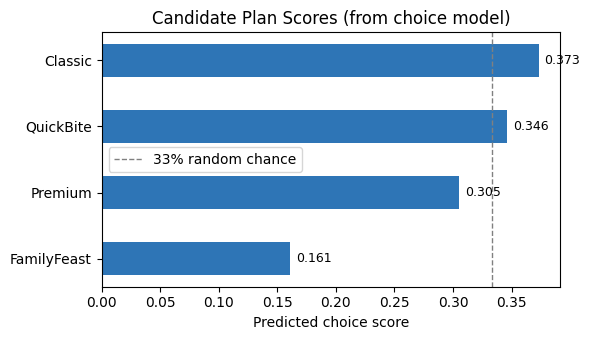

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

plans_df = (pd.DataFrame({'plan': list(SCORES.keys()), 'score': list(SCORES.values())})
              .sort_values('score'))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(plans_df['plan'], plans_df['score'], color='#2E75B6', height=0.5)
ax.axvline(0.333, color='gray', linestyle='--', linewidth=1, label='33% random chance')
ax.set_xlabel('Predicted choice score')
ax.set_title('Candidate Plan Scores (from choice model)')
ax.legend()
for bar, v in zip(ax.patches, plans_df['score']):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

## Decision Memo: Meal Kit Plan Launch Recommendation

**Date:** [Your date]  |  **Analyst:** [Your name]

---

### Executive Summary

Six analytical methods were applied to customer preference, trial adoption,
positioning, attitudinal survey, and marketing data. Evidence consistently
points to the **Classic plan at $55/week** as the recommended launch configuration.

---

### 1. Plan Recommendation

**Recommend: Classic plan at $55/week**

The Classic plan achieves the highest predicted choice score (0.373) across
all four candidate plans, outperforming the feature-rich Premium plan (0.305)
because its $30 lower price makes it competitive across a broader customer base.

---

### 2. Pricing and Willingness to Pay

**Recommended price: $55/week**

Customer WTP for dietary accommodation (the top preference driver) is approximately
$19.29/week. The Classic plan's $20 premium over QuickBite ($35) is within this
WTP estimate. WTP for live cooking class ($11.13) and premium cuisine ($10.18)
supports a future Premium upsell path once the base is established.

---

### 3. Trial Offer Effectiveness

**Recommendation: Scale the "first box free" offer with targeting refinement.**

After adjusting for selection bias using IPW, the offer shows a positive conversion
lift of 8.06 percentage points and $2.56/user in month-1 revenue. The naive
estimate (12.08pp, $3.87) overstates this by ~4pp — the gap reflects targeting
bias (larger households and more-engaged users were both more likely to receive
the offer AND convert regardless of the offer). The adjusted effect remains
positive and meaningful.

---

### 4. Market Positioning

**Positioning angle: Entry-to-mid-tier differentiated from QuickBite on dietary options.**

MDS positioning shows QuickBite and Classic as closest feature-space substitutes
(distance = 2.94). Classic messaging must clearly communicate its dietary
accommodation advantage to avoid cannibalizing QuickBite. Premium and FamilyFeast
occupy sufficiently distinct positions.

Customer segment guidance from factor analysis:
- Broadly engaged customers (Factor 1 — overall satisfaction): target for Premium upsells and referrals.
- Quality-oriented customers (Factor 2 high scorers): "Premium ingredients, chef-designed recipes."
- Budget-first customers (Factor 2 low scorers): "The most meals per dollar of any plan."
- Convenience-first customers (Factor 3): "Ready in 20 minutes. No meal planning required."

---

### 5. Marketing Budget

Prioritize: spend_influencer (coefficient ≈ +0.090) and spend_search (≈ +0.049).
Flag for investigation: spend_email (≈ −3.06), spend_social (≈ −0.87), and spend_affiliate (≈ −0.54) — these likely reflect counter-cyclical deployment patterns, not causal revenue destruction.
*"MMM results are correlational (directional), not causal."*
Run a holdout experiment (e.g., pause influencer spend in one region for 4 weeks) before significant channel reallocation.

---

### Assumptions and Limitations

- **Choice model / WTP:** Stated-preference data; revealed WTP may differ.
  Additivity assumption does not capture feature interaction effects.
- **WTP:** Valid only within the tested price range ($30–$110/week).
- **IPW:** Unconfoundedness is required but untestable. Unobserved factors
  (e.g., intent-to-subscribe at time of offer receipt) may remain as residual bias.
- **MDS:** Feature-space proximity approximates perceptual similarity; validate
  with customer perception survey data where available.
- **MMM:** Coefficients are correlational and sensitive to multicollinearity.
  Large budget reallocations require experimental validation.

---

### Next Steps

1. **Randomized holdout test:** Assign 10% of prospective users to a no-offer
   control group to establish causal conversion estimates before scaling.
2. **A/B pricing test:** Test Classic at $50 vs $55 vs $60 to calibrate real-world
   price elasticity.
3. **Channel holdout:** Reduce email volume in one region for 4 weeks to test
   whether revenue is impacted before reallocating budget.
